<a href="https://colab.research.google.com/github/VadymChubLabs/IAD/blob/main/Lab1_Raisin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота №1
## Базові алгоритми класифікації у Scikit-learn

**Dataset:** Raisin  
**Джерело:** https://archive.ics.uci.edu/dataset/850/raisin

**Мета роботи:** дослідити набір даних Raisin, виконати попередній аналіз і візуалізацію даних, підготувати дані до машинного навчання, навчити кілька базових алгоритмів класифікації з бібліотеки Scikit-learn та порівняти якість їх роботи.

У роботі послідовно розглядаються k-Nearest Neighbors, Decision Tree, Support Vector Machine, Random Forest та AdaBoost. Якість моделей оцінюється на одній і тій самій тестовій вибірці за допомогою accuracy, classification report та confusion matrix.


In [31]:
!pip install ucimlrepo -q

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

## 1. Завантаження та опис набору даних

У роботі використовується набір даних **Raisin** з UCI Machine Learning Repository. Він призначений для задачі **бінарної класифікації**: необхідно визначити, до якого з двох сортів родзинок - **Besni** або **Kecimen** - належить об'єкт.

Датасет містить 900 об'єктів і 7 числових ознак, що описують геометричні характеристики родзинок. Цільовою змінною є `Class`.

Спочатку завантажуємо набір даних через `ucimlrepo`, окремо отримуємо матрицю ознак `X` та цільову змінну `y`.


In [33]:
# Завантаження Raisin Dataset
raisin = fetch_ucirepo(id=850)

# Ознаки та цільова змінна
X = raisin.data.features
y = raisin.data.targets

print("Розмір X:", X.shape)
print("Розмір y:", y.shape)

Розмір X: (900, 7)
Розмір y: (900, 1)


## 2. Первинний аналіз даних

Об'єднуємо вхідні ознаки та цільову змінну в один `DataFrame`, щоб зручно переглядати та аналізувати датасет.

На цьому етапі:
- переглядаємо перші рядки таблиці;
- визначаємо розмір датасету та назви колонок;
- перевіряємо типи даних;
- перевіряємо наявність пропущених значень;
- аналізуємо описову статистику числових ознак;
- перевіряємо кількість класів та їх баланс.

Такий аналіз потрібен, щоб зрозуміти структуру даних і визначити, чи потрібна додаткова попередня обробка перед навчанням моделей.


In [34]:
df = X.copy()
df["Class"] = y["Class"]

df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [35]:
print("Розмір датасету:", df.shape)

print("\nНазви колонок:")
print(df.columns.tolist())

print("\nТипи даних:")
print(df.dtypes)

Розмір датасету: (900, 8)

Назви колонок:
['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter', 'Class']

Типи даних:
Area                 int64
MajorAxisLength    float64
MinorAxisLength    float64
Eccentricity       float64
ConvexArea           int64
Extent             float64
Perimeter          float64
Class               object
dtype: object


In [36]:
print("Кількість пропущених значень:")
print(df.isnull().sum())

Кількість пропущених значень:
Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
Extent             0
Perimeter          0
Class              0
dtype: int64


In [37]:
df.describe()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,87804.127778,430.929950,254.488133,0.781542,91186.090000,0.699508,1165.906636
std,39002.111390,116.035121,49.988902,0.090318,40769.290132,0.053468,273.764315
min,25387.000000,225.629541,143.710872,0.348730,26139.000000,0.379856,619.074000
25%,59348.000000,345.442898,219.111126,0.741766,61513.250000,0.670869,966.410750
50%,78902.000000,407.803951,247.848409,0.798846,81651.000000,0.707367,1119.509000
75%,105028.250000,494.187014,279.888575,0.842571,108375.750000,0.734991,1308.389750
max,235047.000000,997.291941,492.275279,0.962124,278217.000000,0.835455,2697.753000


In [38]:
print("Унікальні класи:")
print(df["Class"].unique())

print("\nКількість об'єктів кожного класу:")
print(df["Class"].value_counts())

Унікальні класи:
['Kecimen' 'Besni']

Кількість об'єктів кожного класу:
Class
Kecimen    450
Besni      450
Name: count, dtype: int64


### Результат первинного аналізу

У наборі даних є **900 об'єктів**, **7 вхідних числових ознак** та одна цільова колонка `Class`.

Пропущені значення відсутні, тому заповнення або видалення пропусків не потрібне. Цільова змінна містить два класи - `Besni` та `Kecimen` - по 450 об'єктів кожного. Отже, датасет є збалансованим, і додаткове балансування класів не потрібне.

Оскільки всі вхідні ознаки є числовими, кодування категоріальних ознак також не потрібне.

## 3. Exploratory Data Analysis (EDA)

Далі виконуємо візуальний аналіз даних.

- Графік розподілу класів дозволяє перевірити баланс цільової змінної.
- Гістограми показують форму розподілу кожної числової ознаки.
- Boxplot допомагає оцінити розкид значень і побачити потенційні викиди.
- Матриця кореляції показує силу та напрямок лінійного зв'язку між числовими ознаками.

Ці візуалізації допомагають краще зрозуміти структуру даних до побудови моделей.


In [39]:
import seaborn as sns

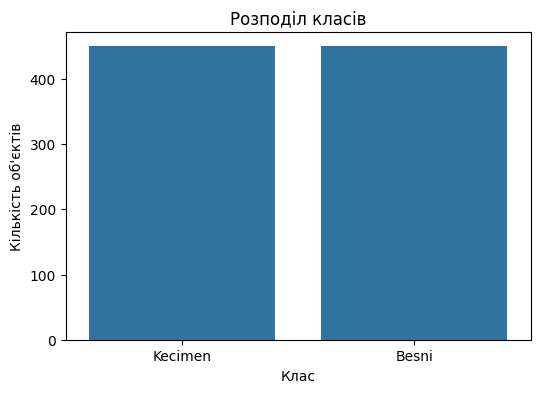

In [40]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Class")

plt.title("Розподіл класів")
plt.xlabel("Клас")
plt.ylabel("Кількість об'єктів")

plt.show()

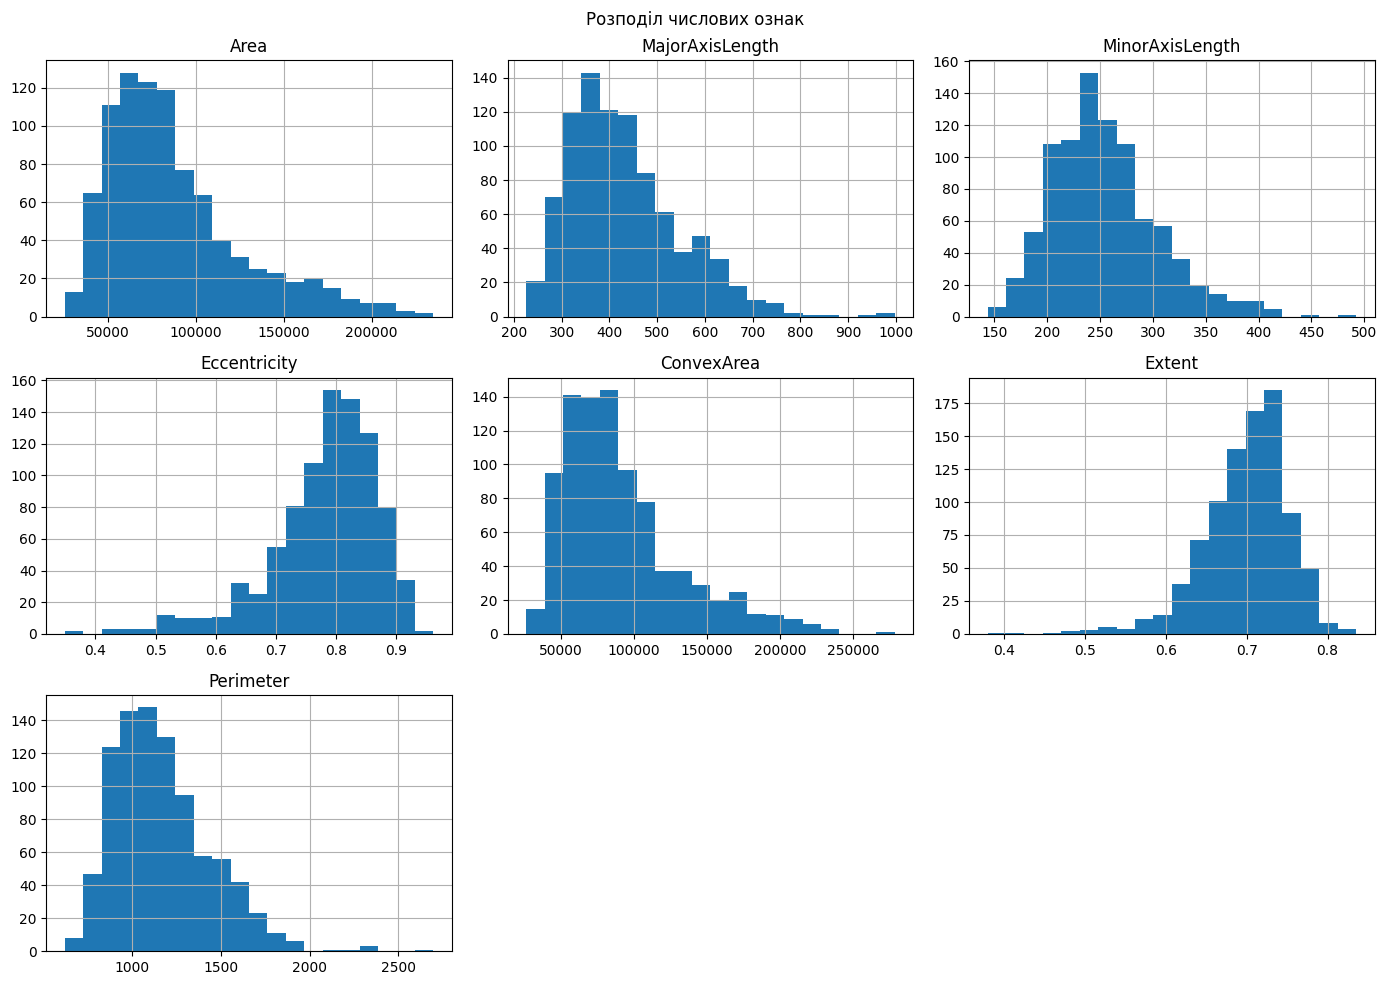

In [41]:
df.drop(columns="Class").hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle("Розподіл числових ознак")
plt.tight_layout()
plt.show()

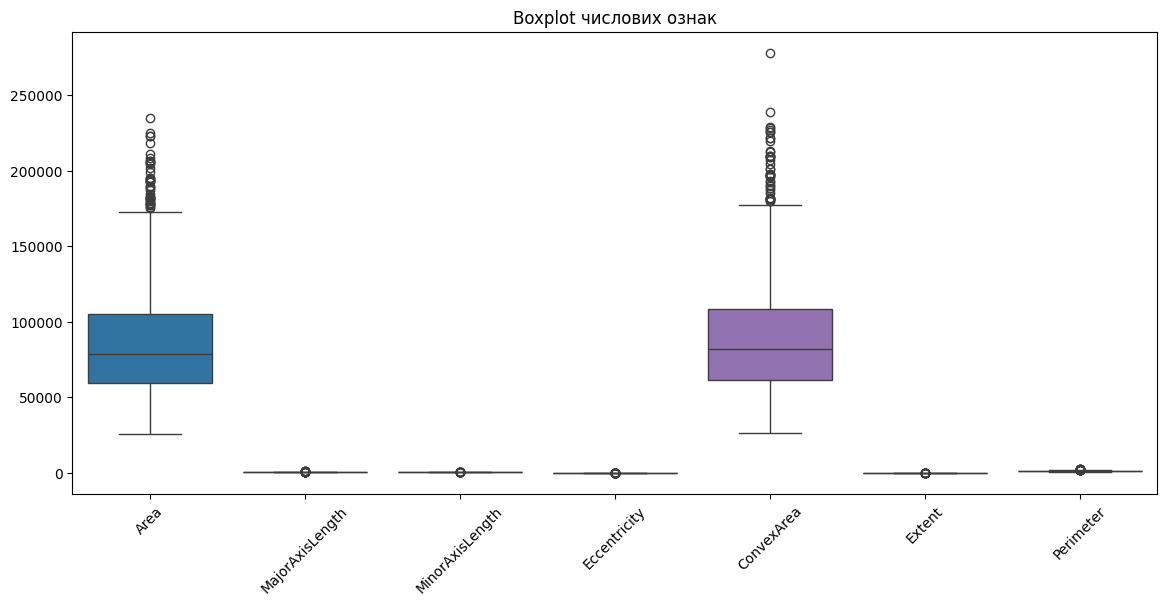

In [42]:
plt.figure(figsize=(14, 6))

sns.boxplot(data=df.drop(columns="Class"))

plt.title("Boxplot числових ознак")
plt.xticks(rotation=45)

plt.show()

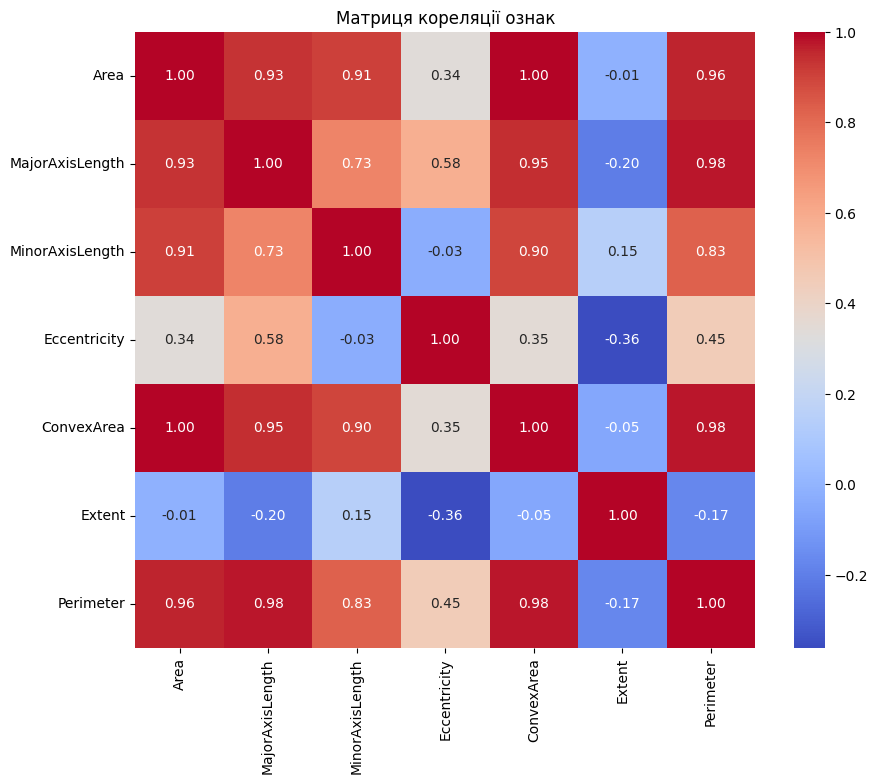

In [43]:
correlation_matrix = df.drop(columns="Class").corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Матриця кореляції ознак")

plt.show()

### Висновок за результатами EDA

Датасет є збалансованим: обидва класи представлені однаковою кількістю об'єктів.

За гістограмами видно, що ознаки мають різні форми розподілу, а boxplot показує наявність значень, що помітно віддаляються від основної маси спостережень. При цьому числові ознаки мають дуже різні масштаби: наприклад, `Area` та `ConvexArea` вимірюються десятками тисяч, тоді як `Eccentricity` і `Extent` мають значення приблизно від 0 до 1.

Матриця кореляції показує сильні позитивні зв'язки між кількома геометричними характеристиками. Зокрема, дуже сильно пов'язані `Area` і `ConvexArea`, а також `Perimeter` з `Area`, `ConvexArea` та `MajorAxisLength`. Це логічно, оскільки більші за розміром об'єкти зазвичай мають більшу площу, периметр і довжину головної осі.

Через різні масштаби ознак для алгоритмів, чутливих до відстаней і масштабу, зокрема kNN та SVM, далі буде виконано стандартизацію даних.


## 4. Підготовка даних до навчання моделей

Перед навчанням відокремлюємо вхідні ознаки `X` від цільової змінної `y` та ділимо дані на навчальну і тестову вибірки.

- **80%** даних використовуються для навчання моделей.
- **20%** залишаються для незалежної перевірки якості.
- `stratify=y` зберігає однакове співвідношення класів у train і test.
- `random_state=42` робить поділ відтворюваним: при повторному запуску отримаємо той самий розподіл.

Тестова вибірка не використовується для навчання або підбору гіперпараметрів і потрібна лише для фінальної оцінки моделей.


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ознаки та цільова змінна
X = df.drop(columns="Class")
y = df["Class"]

# Поділ на навчальну та тестову вибірки
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (720, 7)
X_test: (180, 7)
y_train: (720,)
y_test: (180,)


### Масштабування ознак

Для kNN та SVM важливо, щоб числові ознаки були в порівнянному масштабі. Інакше ознаки з великими числовими значеннями можуть непропорційно сильно впливати на відстані та розділяючу межу.

Використовуємо `StandardScaler`, який стандартизує ознаки. Спочатку викликаємо `fit_transform()` **лише на навчальній вибірці**, а для тестової використовуємо тільки `transform()`.

Це принципово важливо, щоб інформація з тестових даних не потрапила в процес навчання - тобто щоб не виник **data leakage**.


In [45]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Масштабування виконано.")

Масштабування виконано.


## 5. k-Nearest Neighbors (kNN)

kNN класифікує новий об'єкт за класами його найближчих сусідів у просторі ознак.

Ключовий гіперпараметр - `n_neighbors`, тобто кількість сусідів `k`, які враховуються при прийнятті рішення. Надто мале `k` може робити модель чутливою до шуму, а надто велике - надмірно згладжувати межу між класами.

Для підбору `k` використовуємо `GridSearchCV` з 5-кратною крос-валідацією на **навчальній** вибірці. Таким чином тестові дані не використовуються для налаштування моделі.


In [46]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier()

param_grid = {
    "n_neighbors": range(1, 21)
}

grid_knn = GridSearchCV(
    knn,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_knn.fit(X_train_scaled, y_train)

best_k = grid_knn.best_params_["n_neighbors"]

print("Найкраще значення k:", best_k)
print("Найкраща accuracy на крос-валідації:", grid_knn.best_score_)

Найкраще значення k: 16
Найкраща accuracy на крос-валідації: 0.8569444444444445


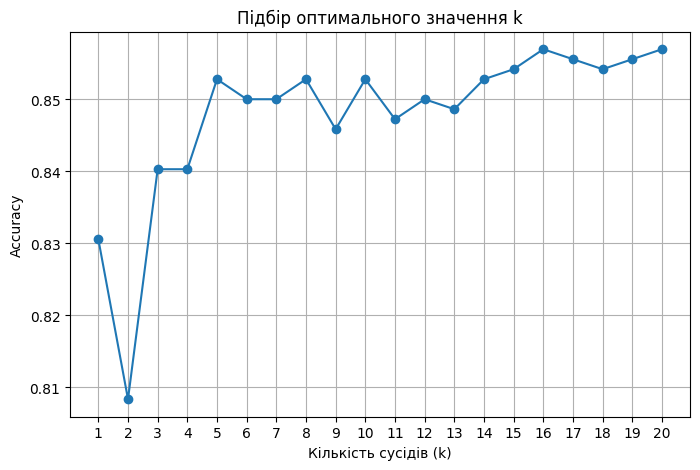

In [47]:
k_values = list(range(1, 21))
cv_accuracies = grid_knn.cv_results_["mean_test_score"]

plt.figure(figsize=(8, 5))

plt.plot(k_values, cv_accuracies, marker="o")

plt.xlabel("Кількість сусідів (k)")
plt.ylabel("Accuracy")
plt.title("Підбір оптимального значення k")
plt.xticks(k_values)
plt.grid()

plt.show()

### Метрики оцінювання моделей

Після навчання кожної моделі оцінюємо її на тестовій вибірці за кількома показниками:

- **Accuracy** - частка всіх правильно класифікованих об'єктів.
- **Precision** - частка правильних прогнозів серед усіх прогнозів певного класу.
- **Recall** - частка об'єктів певного класу, які модель змогла правильно знайти.
- **F1-score** - гармонійне середнє між precision та recall.
- **Confusion matrix** - показує кількість правильних і помилкових прогнозів окремо для кожного класу.

Ці показники дають детальнішу картину якості моделі, ніж одна лише accuracy.


In [48]:
from sklearn.metrics import accuracy_score, classification_report

knn_best = KNeighborsClassifier(n_neighbors=best_k)

knn_best.fit(X_train_scaled, y_train)

y_pred_knn = knn_best.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("Accuracy kNN:", knn_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

Accuracy kNN: 0.8833333333333333

Classification Report:
              precision    recall  f1-score   support

       Besni       0.94      0.82      0.88        90
     Kecimen       0.84      0.94      0.89        90

    accuracy                           0.88       180
   macro avg       0.89      0.88      0.88       180
weighted avg       0.89      0.88      0.88       180



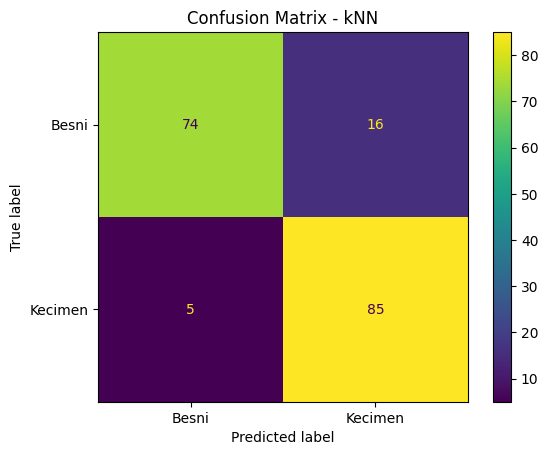

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_knn = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=knn_best.classes_
)

disp.plot()
plt.title("Confusion Matrix - kNN")
plt.show()

### Висновок для kNN

Для алгоритму k-Nearest Neighbors за допомогою GridSearchCV було
підібрано оптимальне значення кількості сусідів k = 16.

На тестовій вибірці модель досягла accuracy ≈ 0.88.
Результати classification report та confusion matrix показують,
що модель достатньо добре розрізняє класи Besni та Kecimen.

## 6. Decision Tree

Decision Tree будує послідовність правил, за якими простір ознак ділиться на області, що відповідають різним класам.

Перевагою дерева є простота інтерпретації та відсутність вимоги до масштабування ознак. Тому тут використовуємо звичайні `X_train` і `X_test`, а не стандартизовані дані.

У цій роботі використовується базова модель `DecisionTreeClassifier` з `random_state=42`, щоб результат був відтворюваним.


In [50]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train, y_train)

y_pred_tree = decision_tree.predict(X_test)

tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Accuracy Decision Tree:", tree_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

Accuracy Decision Tree: 0.8444444444444444

Classification Report:
              precision    recall  f1-score   support

       Besni       0.90      0.78      0.83        90
     Kecimen       0.80      0.91      0.85        90

    accuracy                           0.84       180
   macro avg       0.85      0.84      0.84       180
weighted avg       0.85      0.84      0.84       180



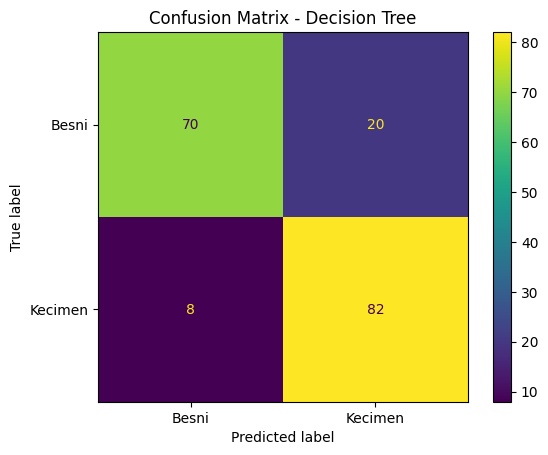

In [51]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=decision_tree.classes_
)

disp.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()

### Висновок для Decision Tree

Модель Decision Tree досягла accuracy ≈ 0.84 на тестовій вибірці.
Результат є нижчим, ніж у kNN.

Матриця помилок показує, що модель правильно класифікувала більшість
об'єктів обох класів, однак допустила більше помилок для класу Besni.

## 7. Support Vector Machine (SVM)

SVM шукає розділяючу межу між класами так, щоб відстань до найближчих навчальних об'єктів була якомога більшою.

Використовується **RBF kernel**, який дозволяє будувати нелінійну межу класифікації.

Основні параметри:
- `C` визначає компроміс між шириною розділяючої межі та кількістю помилок на навчальних даних;
- `gamma` визначає, наскільки локальним є вплив окремих навчальних об'єктів.

Оптимальні `C` і `gamma` підбираємо за допомогою `GridSearchCV`. Оскільки SVM чутливий до масштабу ознак, використовуються `X_train_scaled` та `X_test_scaled`.


In [52]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svm = SVC()

param_grid_svm = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1, 1],
    "kernel": ["rbf"]
}

grid_svm = GridSearchCV(
    svm,
    param_grid_svm,
    cv=5,
    scoring="accuracy"
)

grid_svm.fit(X_train_scaled, y_train)

print("Найкращі параметри:", grid_svm.best_params_)
print("Найкраща accuracy на крос-валідації:", grid_svm.best_score_)

Найкращі параметри: {'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}
Найкраща accuracy на крос-валідації: 0.8666666666666668


In [53]:
svm_best = grid_svm.best_estimator_

y_pred_svm = svm_best.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("Accuracy SVM:", svm_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

Accuracy SVM: 0.8722222222222222

Classification Report:
              precision    recall  f1-score   support

       Besni       0.94      0.80      0.86        90
     Kecimen       0.83      0.94      0.88        90

    accuracy                           0.87       180
   macro avg       0.88      0.87      0.87       180
weighted avg       0.88      0.87      0.87       180



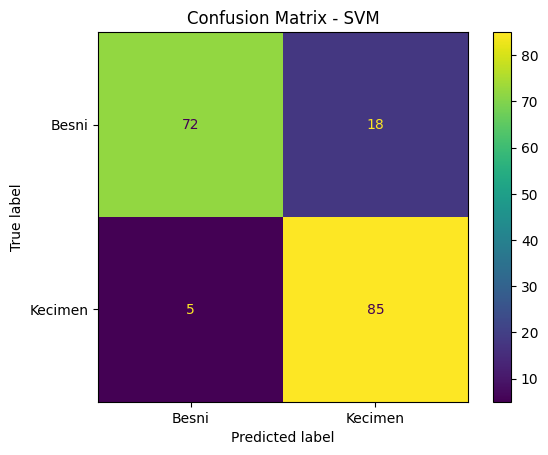

In [54]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=svm_best.classes_
)

disp.plot()
plt.title("Confusion Matrix - SVM")
plt.show()

### Висновок для SVM

За допомогою GridSearchCV було підібрано оптимальні параметри SVM:
C = 0.1, gamma = 0.1, kernel = 'rbf'.

На тестовій вибірці модель досягла accuracy ≈ 0.87.
Результат SVM є кращим за Decision Tree, але трохи нижчим за kNN.

## 8. Random Forest

Random Forest - ансамблевий алгоритм, що складається з великої кількості дерев рішень.

Кожне дерево навчається на дещо іншій підвибірці даних і ознак, а фінальний прогноз формується шляхом об'єднання прогнозів усіх дерев. Такий підхід зазвичай є стабільнішим за одне дерево та допомагає зменшити перенавчання.

У роботі використовуємо `n_estimators=100`, тобто ансамбль зі 100 дерев. Масштабування для Random Forest не потрібне, тому модель навчається на початкових `X_train` і `X_test`.


In [55]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Accuracy Random Forest:", rf_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy Random Forest: 0.8666666666666667

Classification Report:
              precision    recall  f1-score   support

       Besni       0.93      0.79      0.86        90
     Kecimen       0.82      0.94      0.88        90

    accuracy                           0.87       180
   macro avg       0.88      0.87      0.87       180
weighted avg       0.88      0.87      0.87       180



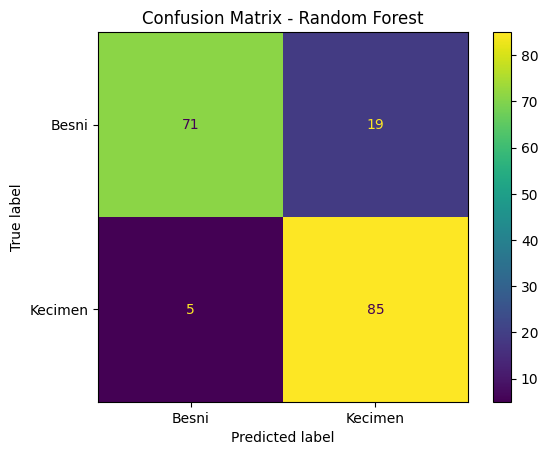

In [56]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=random_forest.classes_
)

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

### Висновок для Random Forest

Модель Random Forest досягла accuracy ≈ 0.87 на тестовій вибірці.
Модель правильно класифікувала більшість об'єктів обох класів,
але її результат є трохи нижчим за kNN та SVM.

## 9. AdaBoost

AdaBoost - ансамблевий метод, який послідовно навчає слабкі класифікатори.

На наступних кроках більша увага приділяється тим об'єктам, які попередні моделі класифікували неправильно. У результаті кілька простіших моделей об'єднуються в один сильніший класифікатор.

У роботі використовується `n_estimators=100`. Як і для дерев рішень, попереднє масштабування ознак для AdaBoost тут не є необхідним.


In [57]:
from sklearn.ensemble import AdaBoostClassifier

adaboost = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

adaboost.fit(X_train, y_train)

y_pred_ada = adaboost.predict(X_test)

ada_accuracy = accuracy_score(y_test, y_pred_ada)

print("Accuracy AdaBoost:", ada_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ada))

Accuracy AdaBoost: 0.8777777777777778

Classification Report:
              precision    recall  f1-score   support

       Besni       0.91      0.83      0.87        90
     Kecimen       0.85      0.92      0.88        90

    accuracy                           0.88       180
   macro avg       0.88      0.88      0.88       180
weighted avg       0.88      0.88      0.88       180



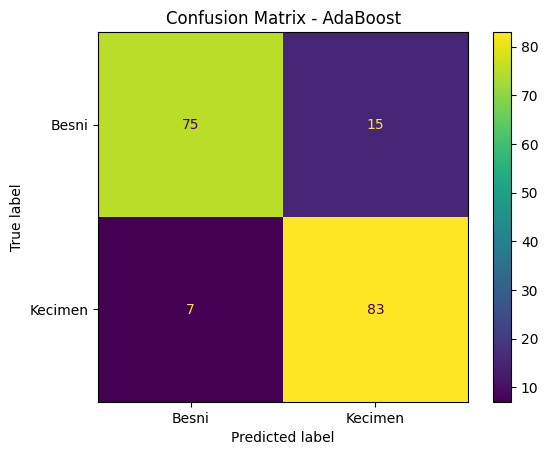

In [58]:
cm_ada = confusion_matrix(y_test, y_pred_ada)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_ada,
    display_labels=adaboost.classes_
)

disp.plot()
plt.title("Confusion Matrix - AdaBoost")
plt.show()

### Висновок для AdaBoost

Модель AdaBoost досягла accuracy ≈ 0.88 на тестовій вибірці.
Результат є одним із найкращих серед досліджених алгоритмів
і лише трохи поступається kNN.

## 10. Порівняння результатів

Після навчання всіх п'яти алгоритмів порівнюємо їх за `accuracy` на **одній і тій самій тестовій вибірці**.

Це дає змогу коректно оцінити, яка з моделей краще узагальнює дані, які вона не бачила під час навчання. Для наочності результати сортуються від найкращого до найгіршого та додатково відображаються на стовпчиковій діаграмі.


In [59]:
results = pd.DataFrame({
    "Модель": [
        "kNN",
        "Decision Tree",
        "SVM",
        "Random Forest",
        "AdaBoost"
    ],
    "Accuracy": [
        knn_accuracy,
        tree_accuracy,
        svm_accuracy,
        rf_accuracy,
        ada_accuracy
    ]
})

results = results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results

,Модель,Accuracy
0,kNN,0.883333
1,AdaBoost,0.877778
2,SVM,0.872222
3,Random Forest,0.866667
4,Decision Tree,0.844444


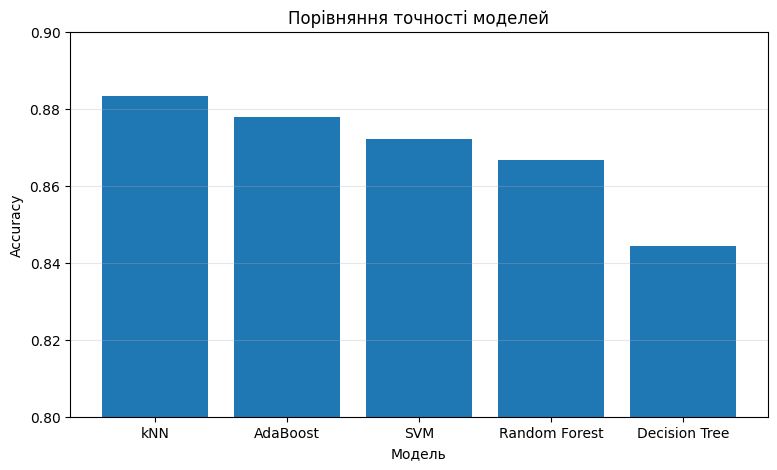

In [60]:
plt.figure(figsize=(9, 5))

plt.bar(
    results["Модель"],
    results["Accuracy"]
)

plt.title("Порівняння точності моделей")
plt.xlabel("Модель")
plt.ylabel("Accuracy")
plt.ylim(0.8, 0.9)
plt.grid(axis="y", alpha=0.3)

plt.show()

## Загальний висновок

У лабораторній роботі було досліджено набір даних **Raisin**, який містить 900 об'єктів, 7 числових ознак та два збалансовані класи - `Besni` і `Kecimen`.

На етапі попереднього аналізу встановлено, що пропущені значення відсутні, а класи представлені однаковою кількістю об'єктів. Було побудовано гістограми, boxplot і матрицю кореляції. Кореляційний аналіз показав сильні зв'язки між кількома геометричними характеристиками, зокрема площею, опуклою площею, периметром і довжиною головної осі.

Дані було поділено на навчальну та тестову вибірки у співвідношенні 80/20 зі збереженням балансу класів. Для kNN та SVM виконано стандартизацію ознак, оскільки ці алгоритми чутливі до різниці масштабів.

Було навчено та протестовано п'ять моделей:
- k-Nearest Neighbors;
- Decision Tree;
- Support Vector Machine;
- Random Forest;
- AdaBoost.

Для kNN за допомогою `GridSearchCV` було підібрано оптимальне значення `k = 16`. Для SVM аналогічно підібрано параметри `C = 0.1`, `gamma = 0.1` та RBF kernel.

На тестовій вибірці отримано такі значення accuracy:
- **kNN - ≈ 0.8833**;
- **AdaBoost - ≈ 0.8778**;
- **SVM - ≈ 0.8722**;
- **Random Forest - ≈ 0.8667**;
- **Decision Tree - ≈ 0.8444**.

Найкращий результат показав **kNN**, однак різниця між kNN, AdaBoost, SVM та Random Forest є невеликою. Це означає, що кілька різних підходів досить добре розв'язують задачу класифікації цього набору даних. Найнижчу точність показало окреме Decision Tree, тоді як ансамблеві методи дали стабільніший результат.

Отже, серед досліджених моделей для набору даних Raisin найефективнішою за показником accuracy виявилася модель **k-Nearest Neighbors**.
